In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits


from scipy.interpolate import interp1d

from specula.mmlib.analyse_data import plot_output_data
from specula.mmlib.plot_gain_opt import plot_gain_optimization
from specula.mmlib.utils import reshape_on_mask, get_pupil_mask
from specula.mmlib.compute_iffs import compute_and_save_influence_functions, compute_and_save_dcao_matrix
# from check_calibration import check_calibration

from specula.lib.make_mask import make_mask

2026-05-19 11:12:10,093 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-19 11:12:10,231 [INFO]: [specula]: Default device is GPU number 0
2026-05-19 11:12:10,814 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-19 11:12:10,814 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-19 11:12:10,816 [INFO]: [specula]: Default device is GPU number 0
2026-05-19 11:12:10,816 [INFO]: [specula]: Default device is GPU number 0
2026-05-19 11:12:10,824 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-19 11:12:10,824 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-19 11:12:10,824 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-19 11:12:10,826 [INFO]: [specula]: Default device is CPU
2026-05-19 11:12:10,826 [INFO]: [specula]: Default device is CPU
2026-05-19 11:12:10,826 [INFO]: [specula]: Default device is CPU


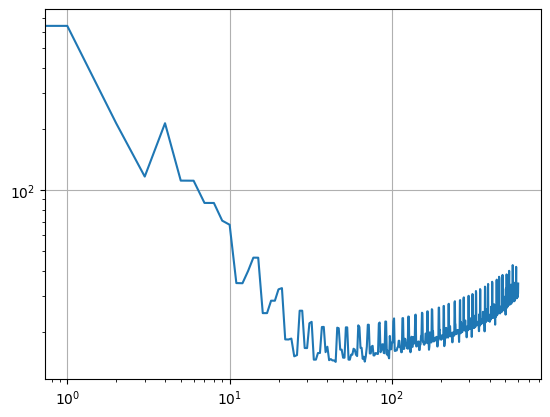

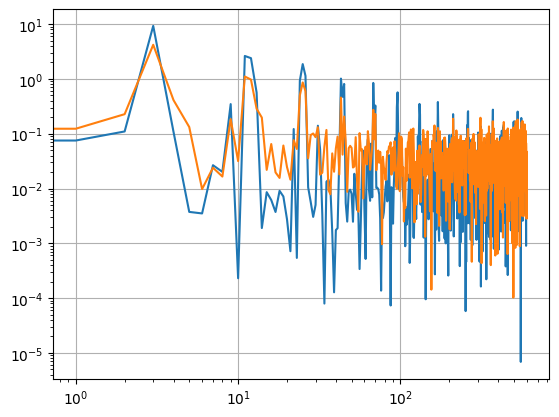

In [24]:
rec = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/rec/pyr3.0_40x40_600modes_rec.fits')
sn = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/slopenulls/pyr3.0_40x40_sn.fits')
sn_pc = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/slopenulls/pyr3.0_40x40_sn_pc.fits')
cov = rec @ rec.T

plt.figure()
plt.loglog(np.diag(cov))
plt.grid()

plt.figure()
plt.loglog(abs(rec @ sn))
plt.loglog(abs(rec @ sn_pc))
plt.grid()

Using data directory: /raid1/mmenessini/results/SOUL/KLv30dx/20260506_092825
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_modes type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
Average Strehl Ratio after 850 iterations: 0.8492
psf.fits file not found in /raid1/mmenessini/results/SOUL/KLv30dx/20260506_092825.
pyr_modes.fits or zwfs_modes.fits file(s) not found in /raid1/mmenessini/results/SOUL/KLv30dx/20260506_092825.
coro_psf.fits file not found in /raid1/mmenessini/results/SOUL/KLv30dx/20260506_092825.
coro_psf_profile.fits file not found in /raid1/mmenessini/results/SOUL/KLv30dx/20260506_092825.


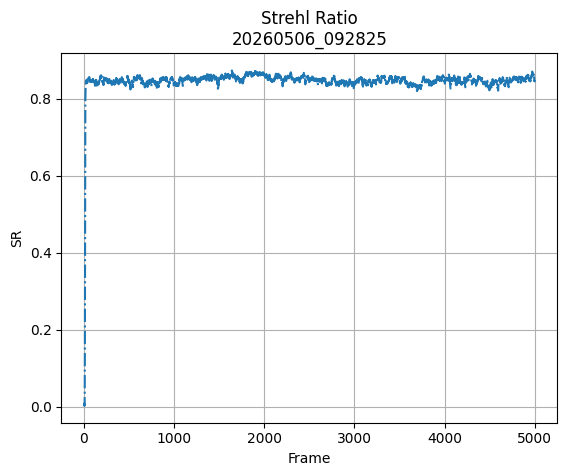

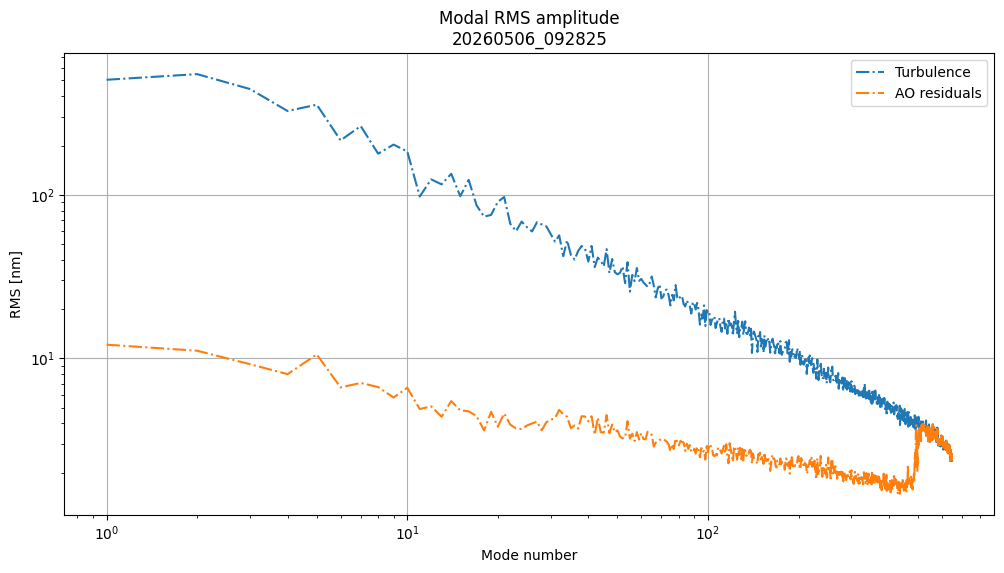

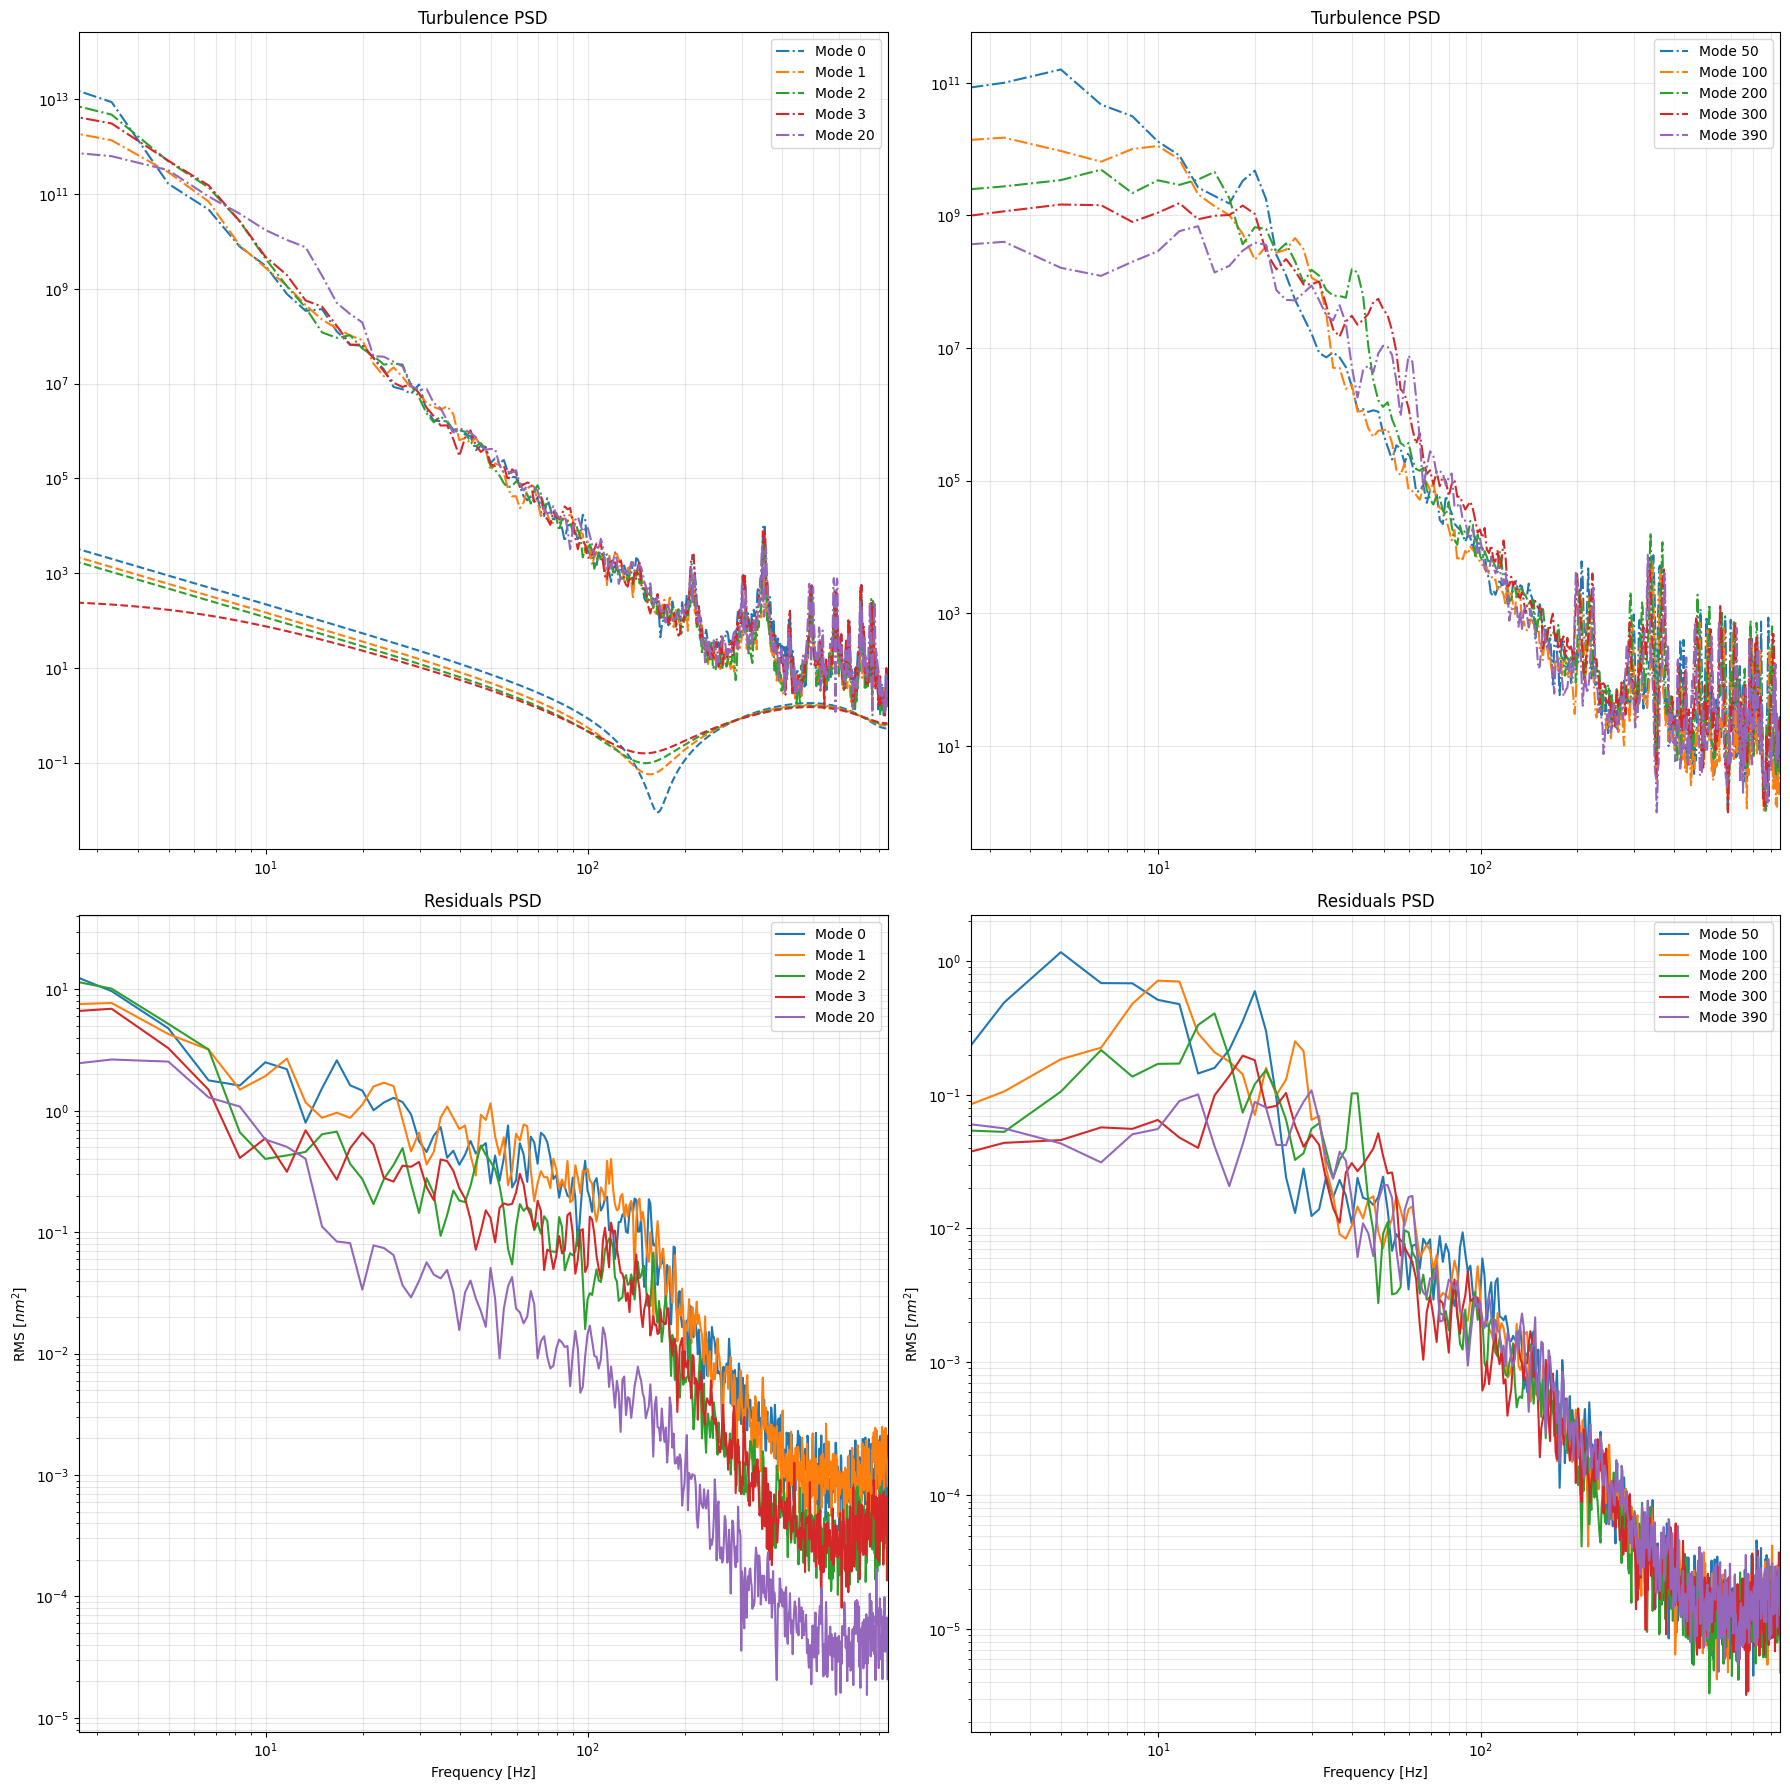

In [23]:
soul_dir = '/raid1/mmenessini/results/SOUL/KLv30dx'
calib_dir = '/raid1/mmenessini/calibration/SOUL/KLv30dx'
plot_output_data(root_dir=soul_dir,calib_dir=calib_dir,tn='20260506_092825')

In [4]:
# iffs = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_ifunc.fits')
# kl = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_kl_inv.fits')
# m2c = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/m2c/asm_v30dx_m2c.fits')

# c2m = np.linalg.pinv(m2c)

In [5]:
# frames = fits.getdata('/raid1/mmenessini/LBTData/20260421/Frames_20260421_054858.fits')
# modes = fits.getdata('/raid1/mmenessini/LBTData/20260421/Modes_20260421_054858.fits')
# slopes = fits.getdata('/raid1/mmenessini/LBTData/20260421/Slopes_20260421_054858.fits')
# positions = fits.getdata('/raid1/mmenessini/LBTData/20260421/Positions_20260421_054858.fits')
# act_cmds = fits.getdata('/raid1/mmenessini/LBTData/20260421/Commands_20260421_054858.fits')
# close_loop = fits.getdata('/raid1/mmenessini/LBTData/20260421/LoopClosed_20260421_054858.fits')
# dimm = fits.getdata('/raid1/mmenessini/LBTData/20260421/Dimm_20260421_054858.fits')

# cmds = (c2m @ act_cmds.T).T

# pol_modes = modes[:,:cmds.shape[1]]+cmds
# # pol_modes = modes+positions

# modes_rms = np.sqrt(np.mean(modes**2,axis=0))
# cmds_rms = np.sqrt(np.mean(cmds**2,axis=0))
# pos_rms = np.sqrt(np.mean(positions**2,axis=0))
# pol_rms = np.sqrt(np.mean(pol_modes**2,axis=0))

# print(positions.shape,slopes.shape)
# # print(dimm.shape,modes.shape,cmds.shape,close_loop.shape)

# # plt.figure()
# # plt.imshow(frames[100])

# # plt.figure()
# # plt.plot(close_loop)

# plt.figure()
# plt.plot(cmds_rms,label='CMD RMS')
# plt.plot(pos_rms,label='POS RMS')
# # plt.plot(modes_rms[:649],label='Mode RMS')
# plt.legend()
# plt.grid()

In [6]:

# plt.figure()
# # plt.plot(pol_modes[0])
# # plt.plot(modes[0])
# plt.loglog(np.arange(len(pol_rms))+1,pol_rms)
# plt.loglog(np.arange(len(modes_rms))+1,modes_rms)
# plt.grid()
# plt.xlabel('KL mode #')
# plt.ylabel('RMS [m]')
# plt.title('20260421_054858')
# # plt.ylim([1e-9,2e-6])

In [7]:
# iffs = fits.getdata('/raid1/mmenessini/calibration/SOUL/ifunc/asm_ifunc.fits')
# m2c = fits.getdata('/raid1/mmenessini/calibration/SOUL/m2c/asm_m2c.fits')

In [8]:
# phs = fits.getdata('/raid1/mmenessini/results/SOUL/20260421_125415/phs.fits')
# mask = (1-phs[0,0,:,:]).astype(bool)
# phs = phs[:,1]

# def show_screen(phs,id:int,mask=mask):
#     # plt.figure()
#     phase = phs[id]
#     plt.imshow(np.ma.masked_array(phase,mask=mask),origin='lower',cmap='RdBu')
#     plt.colorbar()
#     phi_2d = phase - np.mean(phase[~mask])
#     return phi_2d

In [9]:
# cmds = fits.getdata('/raid1/mmenessini/results/SOUL/20260421_125415/asm_commands.fits')

# def show_cmd(cmds,id:int,mask=mask):
#     data = iffs @ cmds[id]
#     img = reshape_on_mask(data,mask)
#     plt.imshow(np.ma.masked_array(img,mask=mask),origin='lower',cmap='RdBu')
#     plt.colorbar()
#     return img

In [10]:
# def show_res_screen(id:int):
#     plt.figure(figsize=(16,4))
#     plt.subplot(1,3,1)
#     phi=show_screen(phs,id)
#     plt.title('Atmo residual (true)')
#     plt.subplot(1,3,2)
#     phi_fit=show_cmd(cmds,id)
#     plt.title('Atmo residual (ASM fit)')
#     plt.subplot(1,3,3)    
#     plt.imshow(np.ma.masked_array(phi-phi_fit,mask=mask),origin='lower',cmap='RdBu')
#     plt.colorbar()
#     plt.title('Fitting error')
#     plt.tight_layout()

# show_res_screen(10)
# show_res_screen(80)

In [11]:
# 0.000588*648*2

In [12]:
# pyr_modes = fits.getdata('/raid1/mmenessini/calibration/SOUL/scratch_aliasing/pyr_modes.fits')

# pyr_modes = np.sqrt(np.mean(pyr_modes**2,axis=0))

# plt.figure()
# plt.plot(pyr_modes)
# plt.xscale('log')
# plt.grid()

18.834328 22.438847 25.946245
20.55237212586421


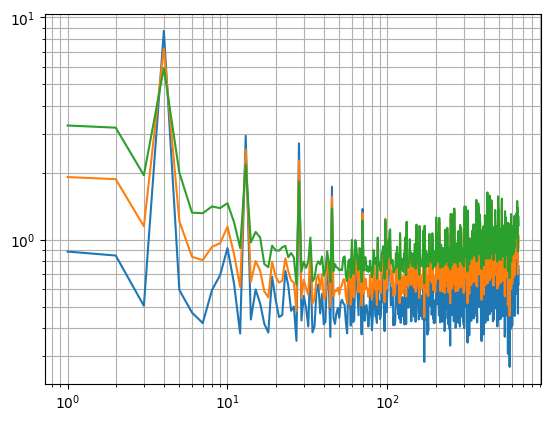

In [13]:
# import os.path as op
alias06 = fits.getdata('/raid1/mmenessini/calibration/SOUL/aliasing/pyr3.0_40x40_s0.6_660modes_alias.fits')
alias10 = fits.getdata('/raid1/mmenessini/calibration/SOUL/aliasing/pyr3.0_40x40_s1.0_660modes_alias.fits')
alias14 = fits.getdata('/raid1/mmenessini/calibration/SOUL/aliasing/pyr3.0_40x40_s1.4_660modes_alias.fits')

x660 = np.arange(660)+1
plt.figure()
plt.loglog(x660,alias06)
plt.loglog(x660,alias10)
plt.loglog(x660,alias14)
plt.grid(which='both')

aliasRMS06 = np.sqrt(np.sum(alias06**2))
aliasRMS10 = np.sqrt(np.sum(alias10**2))
aliasRMS14 = np.sqrt(np.sum(alias14**2))

print(aliasRMS06,aliasRMS10,aliasRMS14)
print(np.sqrt((np.sum((np.ones(660)*0.8)**2))))

In [14]:
N = 54
atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s0.6_{N}modes_atmo.fits')
atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))
print(np.sqrt(np.sum(atmo_modes[:N]**2)))
atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s0.8_{N}modes_atmo.fits')
atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))
print(np.sqrt(np.sum(atmo_modes[:N]**2)))
atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s1.0_{N}modes_atmo.fits')
atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))
print(np.sqrt(np.sum(atmo_modes[:N]**2)))
atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s1.2_{N}modes_atmo.fits')
atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))
print(np.sqrt(np.sum(atmo_modes[:N]**2)))
atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s1.4_{N}modes_atmo.fits')
atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))
print(np.sqrt(np.sum(atmo_modes[:N]**2)))

120.00357
167.83386
215.351
265.75635
322.44412


<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3340694/2026984214.py:22: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')
/tmp/ipykernel_3340694/2026984214.py:37: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')


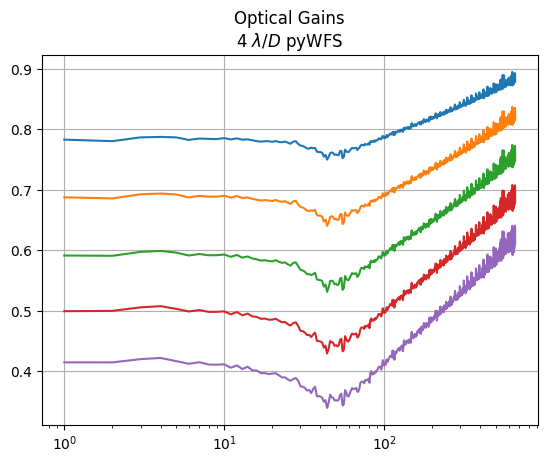

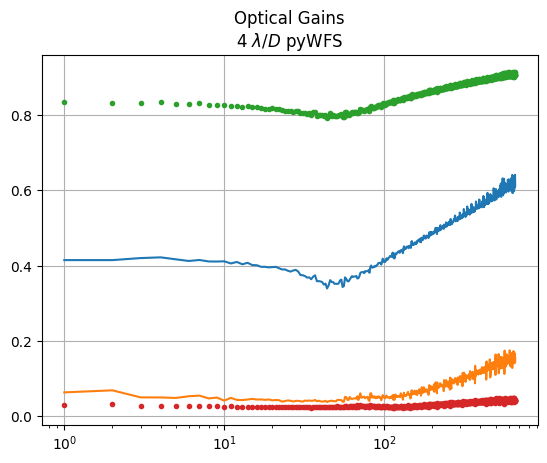

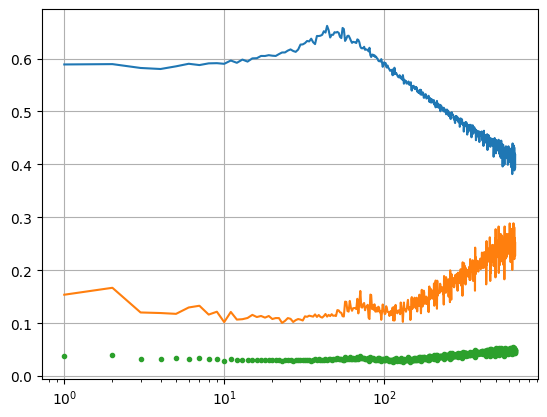

In [15]:
rMod = 4.0

ogs06 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s0.6_100Nm_og.fits')
ogs08 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s0.8_132Nm_og.fits')
ogs10 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.0_169Nm_og.fits')
ogs12 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.2_211Nm_og.fits')
ogs14 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.4_259Nm_og.fits')

im = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/im/pyr{rMod:1.1f}_40x40_im.fits')
simpc = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/im/pyr{rMod:1.1f}_40x40_s1.4_simpc.fits')
im_norm = np.diag(im.T @ im)
og = np.diag(simpc.T @ im)/im_norm
cog = np.sqrt(np.diag(simpc.T @ simpc)/im_norm - og**2)

x = np.arange(len(ogs06))+1
plt.figure()
plt.plot(x,ogs06)
plt.plot(x,ogs08)
plt.plot(x,ogs10)
plt.plot(x,ogs12)
plt.plot(x,ogs14)
plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')
plt.xscale('log')
plt.grid()

plt.figure()
plt.plot(x,og)
plt.plot(x,cog)

im2 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/im/pyr{rMod:1.1f}_40x40_s1.2_simpc.fits')
im2_norm = np.diag(im2.T @ im2)
og2 = np.diag(simpc.T @ im2)/im2_norm
cog2 = np.sqrt(np.diag(simpc.T @ simpc)/im2_norm - og2**2)

plt.plot(x,og2,'.')
plt.plot(x,cog2,'.')
plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')
plt.xscale('log')
plt.grid()

err = np.sqrt((1-og)**2+cog**2)
err_ogc = cog/og
err_ogc2 = cog2/og2

plt.figure()
plt.plot(x,err)
plt.plot(x,err_ogc)
plt.plot(x,err_ogc2,'.')
plt.xscale('log')
plt.grid()

<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:77: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:77: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3340694/2985049538.py:23: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')
/tmp/ipykernel_3340694/2985049538.py:77: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'OG estimation error\n{rMod:1.0f} $\lambda/D$ pyWFS')


57.66451603387616 2
64.57949274151 2
68.14698682261782 2
68.43732132751707 2
65.72947887333316 2
59.479267322975886 3
67.98548416185842 3
73.68797600430814 3
60.83756357206371 4
70.44143123870116 4
62.00405070165294 5
72.54392684120504 5
63.148162217271924 6
74.6468431867928 6


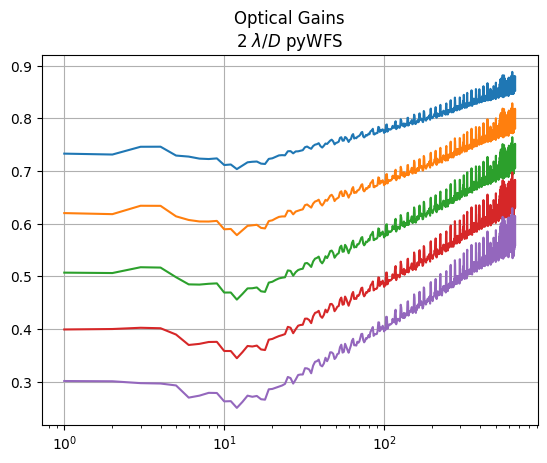

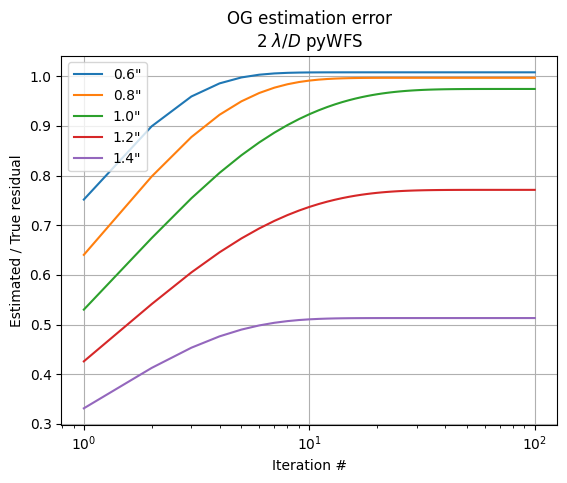

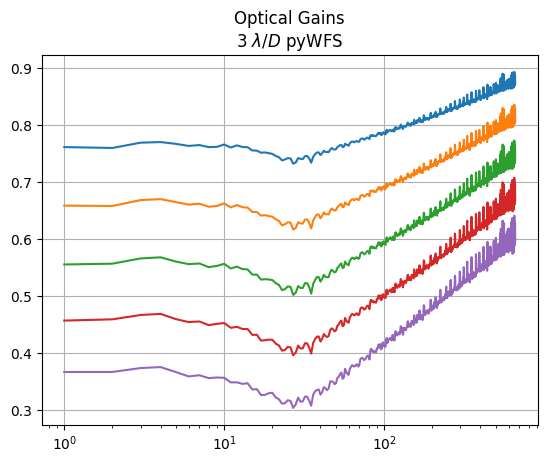

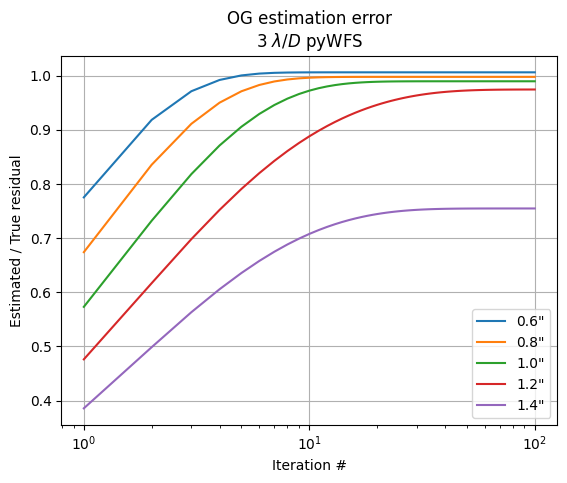

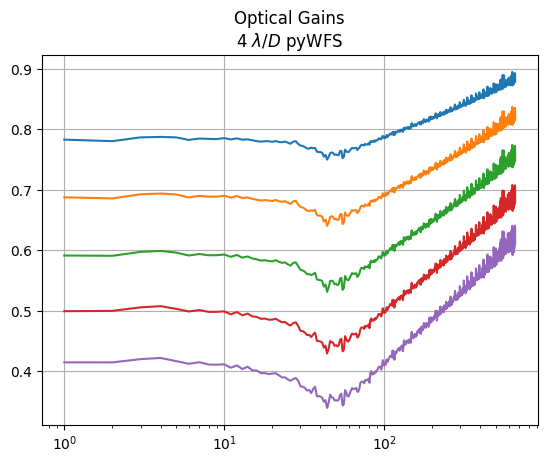

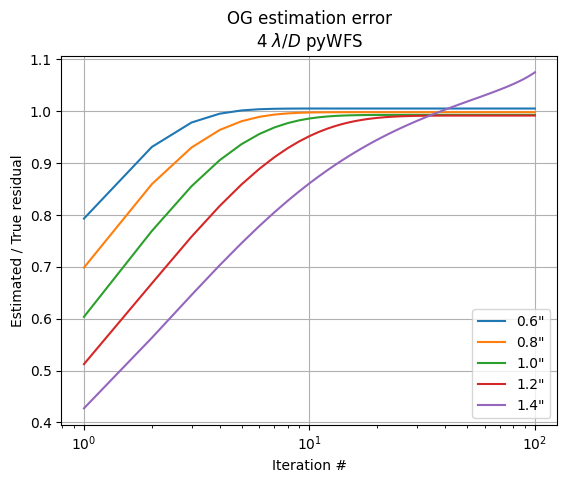

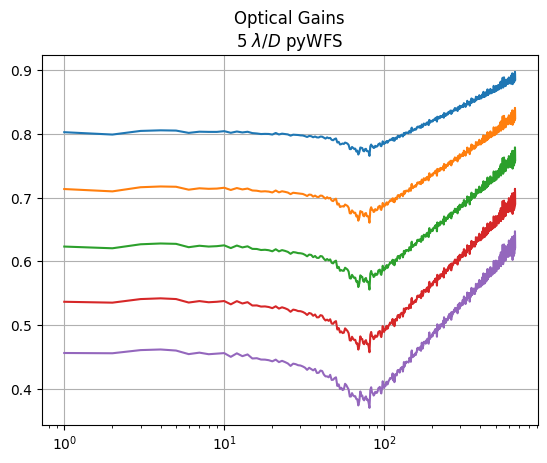

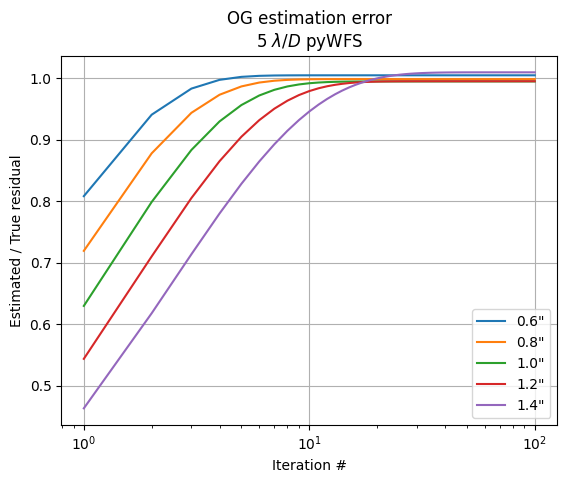

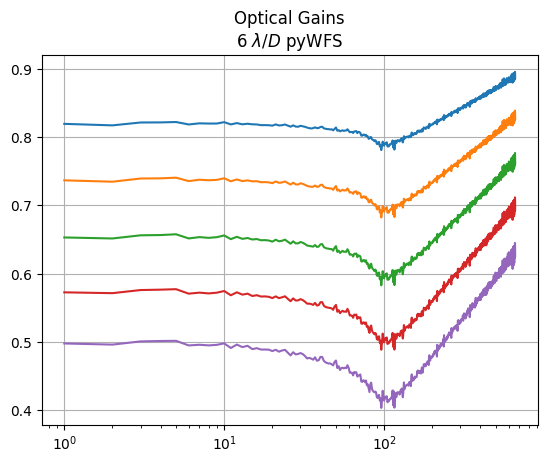

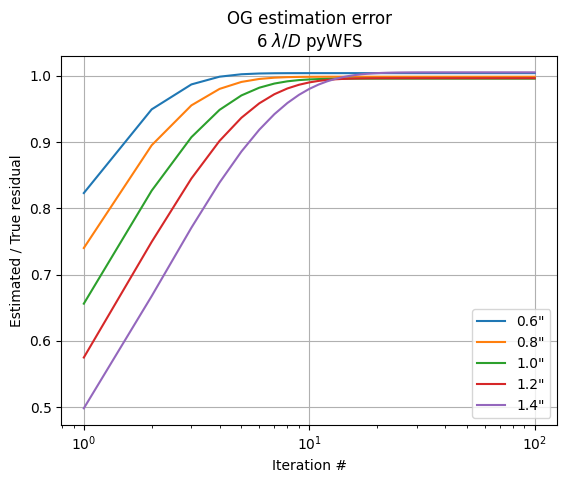

In [16]:
rMods = np.array([2,3,4,5,6])
res = np.array([76,101,129,161,198])

for k,rMod in enumerate(rMods):

    ogs06 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s0.6_100Nm_og.fits')
    ogs08 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s0.8_132Nm_og.fits')
    ogs10 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.0_169Nm_og.fits')
    ogs12 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.2_211Nm_og.fits')
    ogs14 = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/optgains/pyr{rMod:1.1f}_40x40_s1.4_259Nm_og.fits')

    ogs = np.vstack([ogs06,ogs08,ogs10,ogs12,ogs14])
    extrapolator = interp1d(res, ogs, axis=0, kind='cubic', fill_value="extrapolate")
    # extrapolator = interp1d(res, ogs, axis=0, kind='linear', fill_value="extrapolate")

    x = np.arange(len(ogs06))+1
    plt.figure()
    plt.plot(x,ogs06)
    plt.plot(x,ogs08)
    plt.plot(x,ogs10)
    plt.plot(x,ogs12)
    plt.plot(x,ogs14)
    plt.title(f'Optical Gains\n{rMod:1.0f} $\lambda/D$ pyWFS')
    plt.xscale('log')
    plt.grid()

    seeings = np.arange(5)*0.2+0.6
    Nits = 100

    pol_values = np.zeros([len(seeings),Nits])

    for j,seeing in enumerate(seeings):
        og = ogs[j]
        atmo_modes = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/scratch_simpc/s{seeing:1.1f}_660modes_atmo.fits')
        atmo_modes = np.sqrt(np.mean(atmo_modes**2,axis=0))

        atmo_modes = atmo_modes[:len(ogs[0])]
        meas_modes = og * atmo_modes
        x = np.arange(len(atmo_modes))+1

        true_res = np.sqrt(np.sum(atmo_modes**2))
        meas_res = np.sqrt(np.sum(meas_modes**2))

        # plt.figure()
        # plt.plot(x,atmo_modes,label=f'True, res = {true_res:1.0f}')
        # plt.plot(x,meas_modes,'--',label=f'Measured, res = {meas_res:1.0f}')
        # plt.legend()
        # plt.xscale('log')
        # plt.yscale('log')
        # plt.grid()

        pol_res = meas_res
        if pol_res < min(res):
            print(pol_res,rMod)

        # plt.figure()
        # plt.plot(x,og,label=f'True')
        for i in range(100):
            est_ogs = extrapolator(pol_res)
            # if i % 20 == 0:
            #     plt.plot(x,est_ogs,'--',label=f'Iteration {i}, res = {pol_res:1.0f}')
            pol_values[j,i] = pol_res / true_res
            pol_modes = meas_modes / est_ogs
            pol_res = np.sqrt(np.sum(pol_modes**2))
        # plt.legend()
        # plt.xscale('log')
        # plt.grid()

    plt.figure()
    for j,seeing in enumerate(seeings):
        plt.plot(np.arange(Nits)+1,pol_values[j],label=f'{seeing:1.1f}"')
    plt.xscale('log')
    plt.legend()
    plt.grid()
    plt.xlabel('Iteration #')
    plt.ylabel('Estimated / True residual')
    plt.title(f'OG estimation error\n{rMod:1.0f} $\lambda/D$ pyWFS')

In [17]:
# id = 600

# ogs_id = np.array([ogs06[id],ogs08[id],ogs10[id],ogs12[id],ogs14[id]])

# p = np.polyfit(res,ogs_id,2)

# res2 = np.linspace(10,1000)

# plt.figure()
# plt.plot(res,ogs_id,'o')
# plt.plot(res2,np.polyval(p,res2),'--')
# plt.grid()

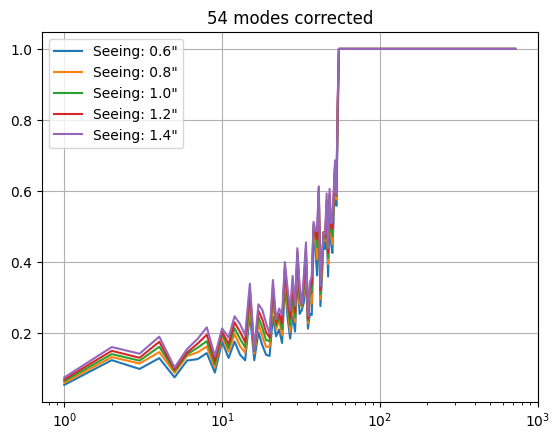

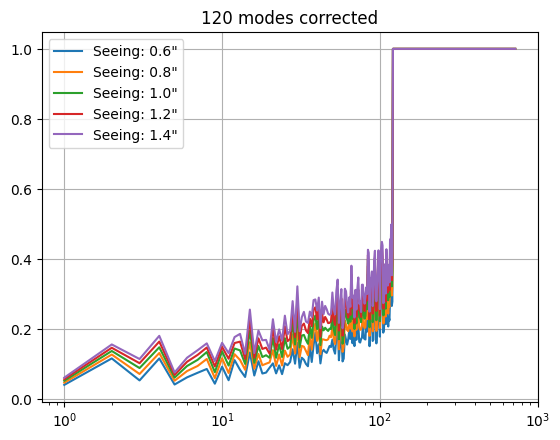

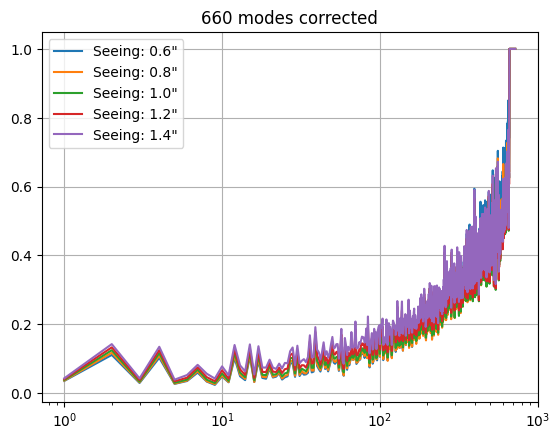

In [18]:
seeings = np.array([0.6,0.8,1.0,1.2,1.4])
modes = np.array([54,120,660])

cv = np.zeros([len(seeings),len(modes),720])

for i,seeing in enumerate(seeings):
    for j,N in enumerate(modes):
        cv[i,j,:] = fits.getdata(f'/raid1/mmenessini/calibration/SOUL/data/s{seeing:1.1f}_{N:1.0f}modes_corrvec.fits')

x = np.arange(720)+1

for j,N in enumerate(modes):
    plt.figure()
    for i,seeing in enumerate(seeings):
        plt.plot(x,1-cv[i,j,:],label=f'Seeing: {seeing:1.1f}"')
    plt.xscale('log')
    plt.legend()
    plt.title(f'{N:1.0f} modes corrected')
    plt.grid()